# XGBoost — Strategy A: SMOTE Oversampling

XGBoost is trained using SMOTE oversampling to address the imbalance between diabetes and non-diabetes cases. SMOTE is included in the training pipeline so that synthetic minority samples are generated only within the training folds during cross-validation. Hyperparameter tuning is applied to optimize model complexity, learning rate, tree depth, and sampling parameters.

In [1]:
import pandas as pd
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, roc_auc_score, classification_report, precision_score, recall_score, f1_score

In [2]:
X_train_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_train_final.parquet")
X_test_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_test_final.parquet")

y_train = pd.read_parquet("../DATASETS/PREPROCESSED/y_train.parquet")["diabetes"]
y_test = pd.read_parquet("../DATASETS/PREPROCESSED/y_test.parquet")["diabetes"]

In [3]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3, 0.5]
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_final, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV ROC AUC:", random_search.best_score_)

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best parameters: {'model__subsample': 0.8, 'model__n_estimators': 500, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__gamma': 0.1, 'model__colsample_bytree': 1.0}
Best CV ROC AUC: 0.8230500415618824


## Final Test Set Evaluation

After hyperparameter tuning, the best model is evaluated on the held-out test set. The test set is not resampled and therefore preserves the original class distribution. Performance is assessed using accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

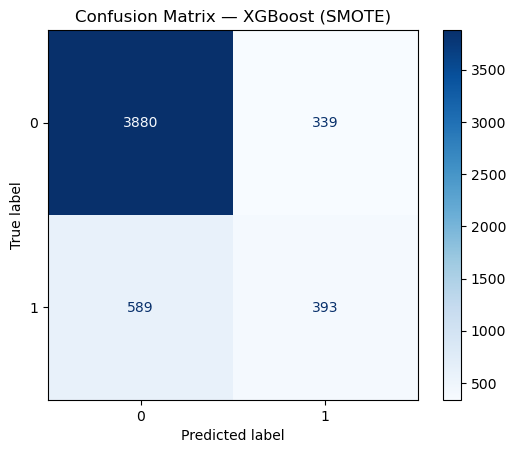

Confusion Matrix:
[[3880  339]
 [ 589  393]]
Accuracy: 0.8216
ROC AUC: 0.8200

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.92      0.89      4219
         1.0       0.54      0.40      0.46       982

    accuracy                           0.82      5201
   macro avg       0.70      0.66      0.68      5201
weighted avg       0.81      0.82      0.81      5201



In [4]:
best_model = random_search.best_estimator_

predictions = best_model.predict(X_test_final)
pred_probabilities = best_model.predict_proba(X_test_final)[:, 1]

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — XGBoost (SMOTE)")
plt.show()

print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, pred_probabilities)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))




## Exporting Model Results

The final evaluation metrics are exported to a CSV file so they can be combined later in a separate model comparison notebook. This avoids retraining models when creating summary tables and visualizations.

In [5]:
metrics = {

    "Strategy": "SMOTE",

    "Model": "XGBoost",

    "Accuracy": accuracy_score(y_test, predictions),

    "Precision": precision_score(y_test, predictions),

    "Recall": recall_score(y_test, predictions),

    "F1-score": f1_score(y_test, predictions),

    "ROC AUC": roc_auc_score(y_test, pred_probabilities)

}

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv("../RESULTS/PERFORMANCE/xgboost_oversampling_metrics.csv", index=False)